<a href="https://colab.research.google.com/github/nickkraus52/MachineLearning/blob/main/HW3/churn_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Data Set Inital Observations

In [91]:
import pandas as pd
df = pd.read_csv("Telco-Customer-Churn.xls")

print("First 5 Rows:")
display(df.head())

First 5 Rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [92]:
print("All Columns and Data Types:")
display(df.info())

All Columns and Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilli

None

In [93]:
display(df['InternetService'].value_counts())
display(df['PaymentMethod'].value_counts())

,count
InternetService,
Fiber optic,3096
DSL,2421
No,1526


,count
PaymentMethod,
Electronic check,2365
Mailed check,1612
Bank transfer (automatic),1544
Credit card (automatic),1522


In [94]:
print("Data Distribution:")
display(df.describe())

Data Distribution:


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## Removal of Unecessary Columns

In [95]:
print("Removing Customer ID")
df.drop(columns=['customerID'], inplace=True)
display(df.info())

Removing Customer ID
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     704

None

## Quantifying Missing or Implicit Missing Values

In [96]:
df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [97]:
from sklearn.impute import SimpleImputer

print('Converting TotalCharges from object to float64:')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print(f'Null values in updated TotalCharges: {df['TotalCharges'].isnull().sum()}')

imputer = SimpleImputer(strategy="median")
df['TotalCharges'] = imputer.fit_transform(df[['TotalCharges']]).ravel()

print(f'Null values in updated TotalCharges: {df['TotalCharges'].isnull().sum()}')

Converting TotalCharges from object to float64:
Null values in updated TotalCharges: 11
Null values in updated TotalCharges: 0


In [98]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("Converted 'Churn' column to numerical:")
display(df['Churn'].value_counts())
display(df['Churn'].dtype)

Converted 'Churn' column to numerical:


,count
Churn,
0,5174
1,1869


dtype('int64')

## Setting up the Pipeline and Attaching SGDClassifier

In [99]:
X = df.drop(columns=['Churn'])
y = df['Churn']

num_features = X.select_dtypes(include=['float64', 'int64']).columns
cat_features = X.select_dtypes(include=['object']).columns

print(f'Numerical Features: {num_features}\n')
print(f'Categorical Features: {cat_features}')

Numerical Features: Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')

Categorical Features: Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')


In [100]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import SGDClassifier

num_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("standardize", StandardScaler())
])

cat_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="constant", fill_value="Unkown")),
    ("encode", OneHotEncoder(handle_unknown="ignore"))
])

preprocessing = ColumnTransformer([
    ("numerical", num_pipeline, num_features),
    ("categorical", cat_pipeline, cat_features)
])

full_pipeline = Pipeline(steps=[("preprocessing", preprocessing)])



X_transform = full_pipeline.fit_transform(X)

display(full_pipeline)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardize',
                                                                   StandardScaler())]),
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                                 ('categorical',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(fill_value='Unkown',
                                                                                 strategy='constant')),
                                                                  ('encode',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))]))])

In [101]:
full_pipeline.steps.append(('clf', SGDClassifier(loss='log_loss', random_state=42)))
display(full_pipeline)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardize',
                                                                   StandardScaler())]),
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                                 ('categorical',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(fill_value='Unkown',
                                                                                 strategy='constant')...
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                ('clf', SGDClassifier(loss='log_loss', random_state=42))])

## Splitting Training and Test Sets

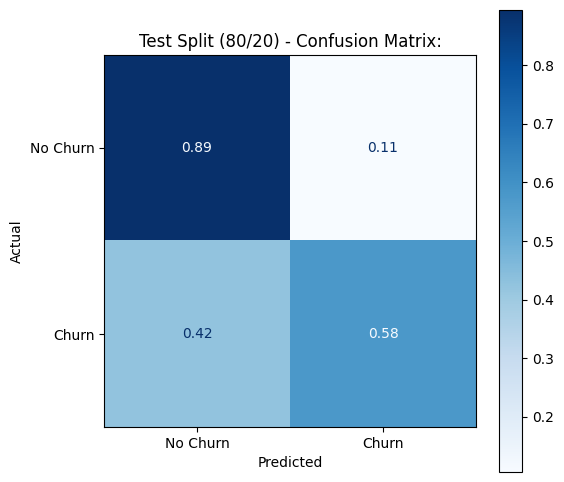


Test Split (80/20) - Classification Report:
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1036
       Churn       0.66      0.58      0.62       373

    accuracy                           0.81      1409
   macro avg       0.76      0.74      0.75      1409
weighted avg       0.80      0.81      0.81      1409





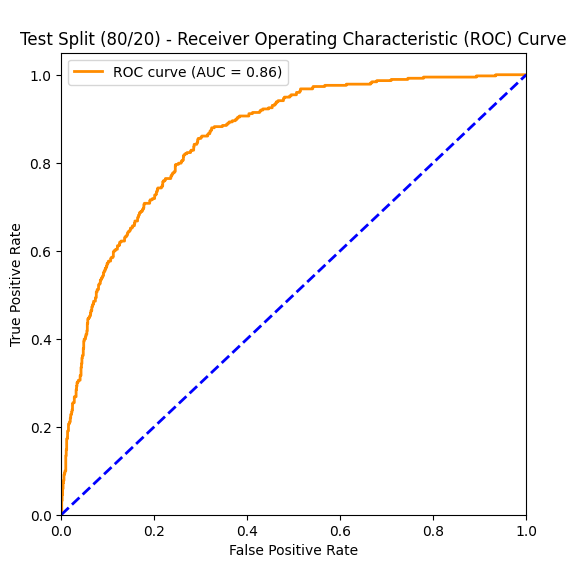

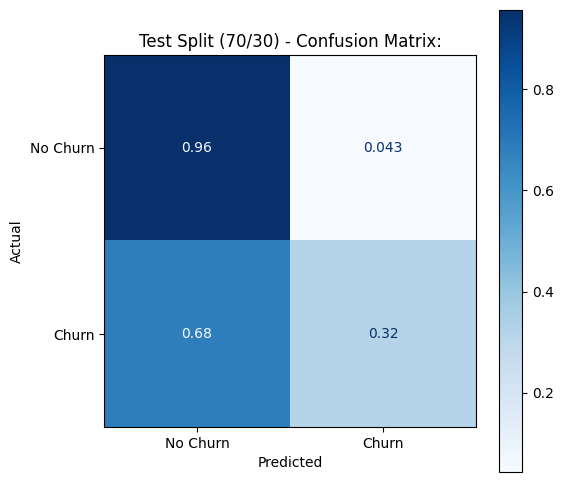


Test Split (70/30) - Classification Report:
              precision    recall  f1-score   support

    No Churn       0.79      0.96      0.87      1539
       Churn       0.74      0.32      0.45       574

    accuracy                           0.78      2113
   macro avg       0.76      0.64      0.66      2113
weighted avg       0.78      0.78      0.75      2113





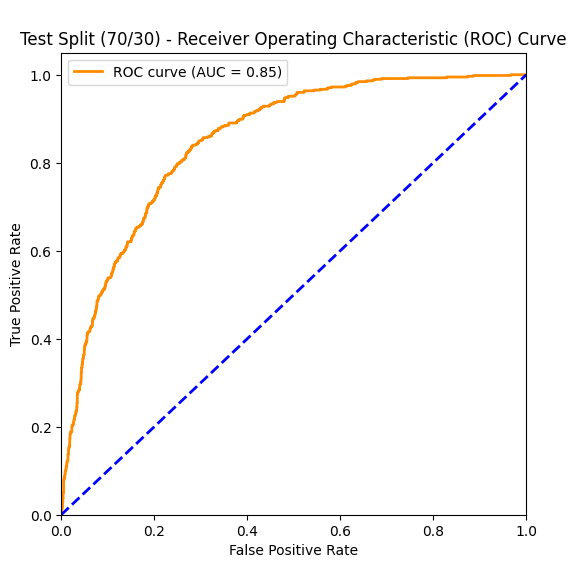

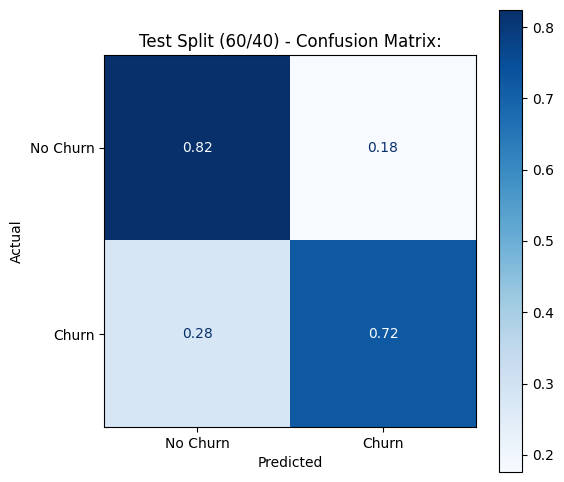


Test Split (60/40) - Classification Report:
              precision    recall  f1-score   support

    No Churn       0.89      0.82      0.86      2069
       Churn       0.60      0.72      0.65       749

    accuracy                           0.80      2818
   macro avg       0.74      0.77      0.76      2818
weighted avg       0.81      0.80      0.80      2818





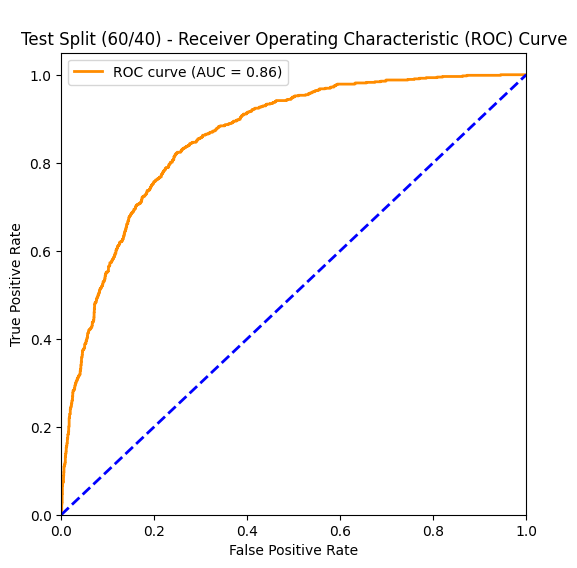

In [102]:
from numpy import test
from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_curve, auc, ConfusionMatrixDisplay, accuracy_score, f1_score
import matplotlib.pyplot as plt

testSizes = [(0.2, "80/20"), (0.3, "70/30"), (0.4, "60/40")]
for testSize, split in testSizes:
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=testSize, random_state=42)

  test_pipeline = clone(full_pipeline)
  test_pipeline.fit(X_train, y_train)

  y_pred = test_pipeline.predict(X_test)
  y_proba = test_pipeline.predict_proba(X_test)[:, 1]

  fig, ax = plt.subplots(figsize=(6, 6))
  ConfusionMatrixDisplay.from_estimator(test_pipeline, X_test, y_test, ax=ax, cmap='Blues', normalize='true', display_labels=['No Churn', 'Churn'])
  plt.xlabel('Predicted')
  plt.ylabel('Actual')
  plt.title(f"Test Split ({split}) - Confusion Matrix:")
  plt.show()

  print(f"\nTest Split ({split}) - Classification Report:")
  print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))
  print('\n')

  fpr, tpr, thresholds = roc_curve(y_test, y_proba)
  roc_auc = auc(fpr, tpr)
  plt.figure(figsize=(6, 6))
  plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
  plt.plot([0, 1], [0, 1], color='blue', lw=2, linestyle='--')
  plt.xlim([0.0, 1.0])
  plt.ylim([0.0, 1.05])
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title(f'\nTest Split ({split}) - Receiver Operating Characteristic (ROC) Curve')
  plt.legend()
  plt.show()
  print('\n')



## **Performance Differences:**

**ROC-AUC** stays fairly stagnant between test sizes ranging from 0.85-0.86 which indicates the models fairly consistent at predicting churn risk regardless of test size.

The **F1 Score** for Churn strangely fluctuates in the 70/30 tests being at 0.45 while the other two tests are 0.65 and 0.62, but the No Churn F1 scores are simmilar, so this also reinforces the idea that test size doesn't have a huge effect on model accuracy.

The **Accuracy** scores also stay around the same value ranging from 0.78 - 0.81.

## Inspecting Model Feature Coefficients

In [103]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipeline = clone(full_pipeline)
pipeline.fit(X_train, y_train)

feature_names = pipeline.named_steps['preprocessing'].get_feature_names_out()
coefs = pipeline.named_steps['clf'].coef_[0]

coef_df = pd.DataFrame({'feature': feature_names, 'coefficient': coefs})
coef_df['abs_coefficient'] = coef_df['coefficient'].abs()
coef_df = coef_df.sort_values('abs_coefficient', ascending=False)
coef_df.head(20)

,feature,coefficient,abs_coefficient
1,numerical__tenure,-1.476993,1.476993
16,categorical__InternetService_Fiber optic,1.096324,1.096324
36,categorical__Contract_Month-to-month,1.067071,1.067071
2,numerical__MonthlyCharges,-0.862463,0.862463
35,categorical__StreamingMovies_Yes,0.693300,0.693300
18,categorical__OnlineSecurity_No,0.655407,0.655407
8,categorical__Dependents_No,0.614013,0.614013
40,categorical__PaperlessBilling_Yes,0.575621,0.575621
32,categorical__StreamingTV_Yes,0.561617,0.561617
14,categorical__MultipleLines_Yes,0.554323,0.554323


In [104]:
print("5 Strongest Categories indicating No Churn")
coef_df = coef_df.sort_values('coefficient', ascending=False)
display(coef_df.head(5))

5 Strongest Categories indicating No Churn


,feature,coefficient,abs_coefficient
16,categorical__InternetService_Fiber optic,1.096324,1.096324
36,categorical__Contract_Month-to-month,1.067071,1.067071
35,categorical__StreamingMovies_Yes,0.693300,0.693300
18,categorical__OnlineSecurity_No,0.655407,0.655407
8,categorical__Dependents_No,0.614013,0.614013


In [105]:
print("5 Strongest Categories indicating Churn")
coef_df = coef_df.sort_values('coefficient', ascending=True)
display(coef_df.head(5))

5 Strongest Categories indicating Churn


,feature,coefficient,abs_coefficient
1,numerical__tenure,-1.476993,1.476993
2,numerical__MonthlyCharges,-0.862463,0.862463
38,categorical__Contract_Two year,-0.448739,0.448739
15,categorical__InternetService_DSL,-0.335540,0.335540
12,categorical__MultipleLines_No,-0.031112,0.031112
